# Perceptron Implementation

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import random

### File Reading

In [2]:
# Unpacking helper function
def unpack_data(paired_list):
    labels = [label for label, _ in paired_list]
    data = [features for _, features in paired_list]
    return labels, data

In [3]:
labels = []
numbers = []

with open(os.path.join(os.getcwd(), 'data/MNISTnumLabels5000_balanced.txt'), 'r+') as f:
    lines = f.readlines()
    for line in lines:
        labels.append(int(line))

with open(os.path.join(os.getcwd(), 'data/MNISTnumImages5000_balanced.txt'), 'r+') as f:
    lines = f.readlines()
    for line in lines:
        ind_line = line.split('\t')
        ind_line = [float(i) for i in ind_line]

        numbers.append(ind_line)
    

labels = np.array(labels)
numbers = np.array(numbers)

#### Example of how we will be displaying numbers

7


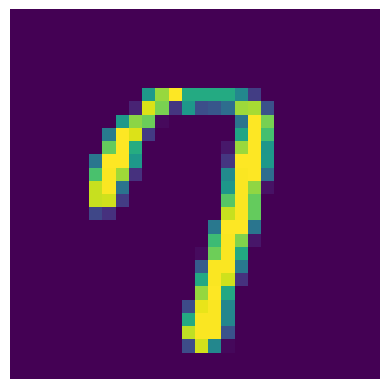

In [4]:
index = random.randint(0, 4999)

example_number = numbers[index]
example_label = labels[index]
matrix = example_number.reshape(28, 28).T

print(example_label)
plt.imshow(matrix)
plt.axis('off')
plt.show()

## Step 1: Data Randomization

In [5]:
zeroes_and_nines_train = []
zeroes_and_nines_test = []
zero_count = 0
nine_count = 0
new_labels = []
test_labels = []
for i in range(len(numbers)):
    if labels[i] == 0 or labels[i] == 9:
        zero_count += 1 if labels[i] == 0 else 0
        nine_count += 1 if labels[i] == 9 else 0

        if labels[i] == 0 and zero_count > 400:
            zeroes_and_nines_test.append(numbers[i])
            test_labels.append(labels[i])
            continue
        
        if labels[i] == 9 and nine_count > 400:
            zeroes_and_nines_test.append(numbers[i])
            test_labels.append(labels[i])
            continue

        zeroes_and_nines_train.append(numbers[i])
        new_labels.append(labels[i])


# Time to shuffle!
combined_train_data = list(zip(new_labels, zeroes_and_nines_train))
random.shuffle(combined_train_data)

combined_test_data = list(zip(test_labels, zeroes_and_nines_test))
random.shuffle(combined_test_data)

In [6]:
len(combined_train_data)

800

In [7]:
# Challenge set
challenge_set = []
challenge_labels = []

# Track how many of each digit (1–8) we’ve taken
digits = {d: 0 for d in range(1, 9)}

for i in range(len(numbers)):
    label = labels[i]  # get the digit for this image
    
    # only use digits 1–8, and only take 100 of each
    if label in digits and digits[label] < 100:
        challenge_set.append(numbers[i])
        challenge_labels.append(label)
        digits[label] += 1

    # if we’ve collected 100 of all 1–8, we can stop
    if all(count == 100 for count in digits.values()):
        break

combined_challenge_data = list(zip(challenge_labels, challenge_set))
random.shuffle(combined_challenge_data)

## Step 2: Perceptron

In [8]:
# I am considering 0 = 0, 1 = 9

w = np.random.uniform(0, 0.5, size=785)  # includes bias weight

def perceptron_run(number_array, w):
    x0 = 1
    input_array = np.insert(number_array, 0, x0)  # prepend bias input
    
    summation = np.dot(w, input_array)  # weighted sum

    # Activation function (step)
    output = 1 if summation > 0 else 0

    return output

## Step 3: Accuracy Scores

In [9]:
def error_fractions(p_output, truths):
    wrong_answer_count = 0

    for i in range(len(p_output)):
        if p_output[i] != truths[i]:
            wrong_answer_count += 1
    
    return wrong_answer_count/len(truths)

def positives_counter(p_output, truths):
    true_positives = 0
    false_positives = 0
    true_negatives = 0
    false_negatives = 0

    for i in range(len(p_output)):
        if p_output[i] == 1 and truths[i] == 1:
            true_positives += 1
        
        elif p_output[i] == 0 and truths[i] == 0:
            true_negatives += 1

        elif p_output[i] == 1 and truths[i] == 0:
            false_positives += 1
        
        elif p_output[i] == 0 and truths[i] == 1:
            false_negatives += 1

    return (true_positives, true_negatives, false_positives, false_negatives)

def precision_score(p_output, truths):
    true_positives, _, false_positives, _ = positives_counter(p_output, truths)

    return (true_positives / (true_positives + false_positives))

def recall_score(p_output, truths):
    true_positives, _, _, false_negatives = positives_counter(p_output, truths)

    return (true_positives / (true_positives + false_negatives))

def f1_score(p_output, truths):
    prec_score = precision_score(p_output, truths)
    rec_score = recall_score(p_output, truths)

    return (2 * ((prec_score * rec_score) / (prec_score + rec_score)))

### Accuracy Scores Before Training

In [11]:
# Initial accuracy tests
perceptron_outputs = []
true_outputs = []

# With the train set
for label, number in combined_test_data:
    perceptron_outputs.append(perceptron_run(number_array=number, w=w))
    true_outputs.append(1 if label == 9 else 0)

before_error_frac = error_fractions(perceptron_outputs, true_outputs)
print(f"Error Fraction: {error_fractions(perceptron_outputs, true_outputs)}")

true_positives, true_negatives, false_positives, false_negatives = positives_counter(perceptron_outputs, true_outputs)
print(f"True positives: {true_positives}, True negatives: {true_negatives}, False positives: {false_positives}, False negatives: {false_negatives}")

before_prec_score = precision_score(perceptron_outputs, true_outputs)
print(f"Precision score: {precision_score(perceptron_outputs, true_outputs)}")

before_rec_score = recall_score(perceptron_outputs, true_outputs)
print(f"Recall score: {recall_score(perceptron_outputs, true_outputs)}")

before_f1_score = f1_score(perceptron_outputs, true_outputs)
print(f"F1 score: {f1_score(perceptron_outputs, true_outputs)}")

Error Fraction: 0.5
True positives: 100, True negatives: 0, False positives: 100, False negatives: 0
Precision score: 0.5
Recall score: 1.0
F1 score: 0.6666666666666666


## Step 4: Training the Perceptron

In [11]:
lr = 0.01
num_epochs = 100
w = np.random.uniform(0, 0.5, size=785)  
w_trained = w.copy()
labels, perc_inputs = unpack_data(combined_train_data)
labels = [0 if lbl == 0 else 1 for lbl in labels]
perc_inputs = perc_inputs
error_frac_threshold = 0.001
error_frac = 1.00

# For time series
epoch_numbers = []
error_fracs = []

epoch_number = 0
while (epoch_number < num_epochs):
    perc_outputs = []
    print(f"Epoch number {epoch_number + 1}", end=' ')
    for index in range(len(perc_inputs)):
        perceptron_outputs = perceptron_run(perc_inputs[index], w_trained)
        perc_outputs.append(perceptron_outputs)

        error = labels[index] - perceptron_outputs

        w_trained = w_trained + (lr * (error) * (np.insert(perc_inputs[index], 0, 1))) 
        w_trained[0] = w_trained[0] + (lr * error)

    error_frac = error_fractions(perc_outputs, labels)
    epoch_number += 1
    epoch_numbers.append(epoch_number)
    error_fracs.append(error_frac)
    print(f"Error fraction: {error_frac}", end='\n')

Epoch number 1 Error fraction: 0.1125
Epoch number 2 Error fraction: 0.02125
Epoch number 3 Error fraction: 0.015
Epoch number 4 Error fraction: 0.01125
Epoch number 5 Error fraction: 0.01
Epoch number 6 Error fraction: 0.0075
Epoch number 7 Error fraction: 0.0075
Epoch number 8 Error fraction: 0.0075
Epoch number 9 Error fraction: 0.00375
Epoch number 10 Error fraction: 0.005
Epoch number 11 Error fraction: 0.00375
Epoch number 12 Error fraction: 0.005
Epoch number 13 Error fraction: 0.0025
Epoch number 14 Error fraction: 0.0025
Epoch number 15 Error fraction: 0.005
Epoch number 16 Error fraction: 0.0025
Epoch number 17 Error fraction: 0.00625
Epoch number 18 Error fraction: 0.00125
Epoch number 19 Error fraction: 0.00125
Epoch number 20 Error fraction: 0.0025
Epoch number 21 Error fraction: 0.0
Epoch number 22 Error fraction: 0.0
Epoch number 23 Error fraction: 0.0
Epoch number 24 Error fraction: 0.0
Epoch number 25 Error fraction: 0.0
Epoch number 26 Error fraction: 0.0
Epoch number

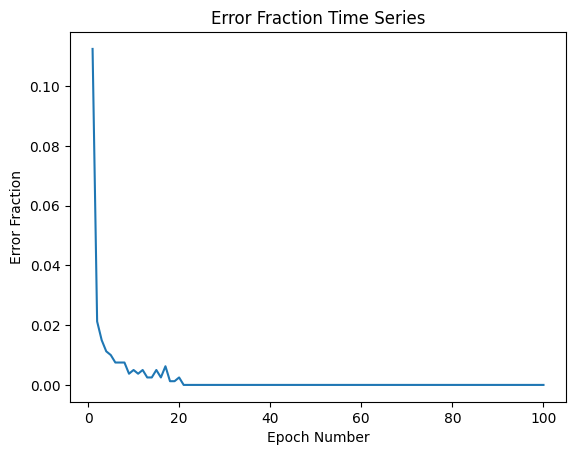

In [12]:
plt.plot(epoch_numbers, error_fracs)
plt.xlabel('Epoch Number')
plt.ylabel('Error Fraction')
plt.title('Error Fraction Time Series')
plt.savefig(os.path.join(os.getcwd(), 'figs/ef_time_series.png'))

### Accuracy Scores After Training

In [32]:
# Testing with train set after training
perceptron_outputs = []
true_outputs = []

# With the train set
for label, number in combined_train_data:
    perceptron_outputs.append(perceptron_run(number_array=number, w=w_trained))
    true_outputs.append(1 if label == 9 else 0)

train_error_frac = error_fractions(perceptron_outputs, true_outputs)
print(f"Error Fraction: {error_fractions(perceptron_outputs, true_outputs)}")

train_true_positives, train_true_negatives, train_false_positives, train_false_negatives = positives_counter(perceptron_outputs, true_outputs)
print(f"True positives: {train_true_positives}, True negatives: {train_true_negatives}, False positives: {train_false_positives}, False negatives: {train_false_negatives}")

train_prec_score = precision_score(perceptron_outputs, true_outputs)
print(f"Precision score: {train_prec_score}")

train_rec_score = recall_score(perceptron_outputs, true_outputs)
print(f"Recall score: {recall_score(perceptron_outputs, true_outputs)}")

train_f1_score = f1_score(perceptron_outputs, true_outputs)
print(f"F1 score: {f1_score(perceptron_outputs, true_outputs)}")

Error Fraction: 0.0
True positives: 400, True negatives: 400, False positives: 0, False negatives: 0
Precision score: 1.0
Recall score: 1.0
F1 score: 1.0


In [33]:
# Testing with train set after training
perceptron_outputs = []
true_outputs = []

# With the train set
for label, number in combined_test_data:
    perceptron_outputs.append(perceptron_run(number_array=number, w=w_trained))
    true_outputs.append(1 if label == 9 else 0)

test_error_frac = error_fractions(perceptron_outputs, true_outputs)
print(f"Error Fraction: {error_fractions(perceptron_outputs, true_outputs)}")

test_true_positives, test_true_negatives, test_false_positives, test_false_negatives = positives_counter(perceptron_outputs, true_outputs)
print(f"True positives: {test_true_positives}, True negatives: {test_true_negatives}, False positives: {test_false_positives}, False negatives: {test_false_negatives}")

test_prec_score = precision_score(perceptron_outputs, true_outputs)
print(f"Precision score: {precision_score(perceptron_outputs, true_outputs)}")

test_rec_score = recall_score(perceptron_outputs, true_outputs)
print(f"Recall score: {recall_score(perceptron_outputs, true_outputs)}")

test_f1_score = f1_score(perceptron_outputs, true_outputs)
print(f"F1 score: {f1_score(perceptron_outputs, true_outputs)}")

Error Fraction: 0.01
True positives: 99, True negatives: 99, False positives: 1, False negatives: 1
Precision score: 0.99
Recall score: 0.99
F1 score: 0.99


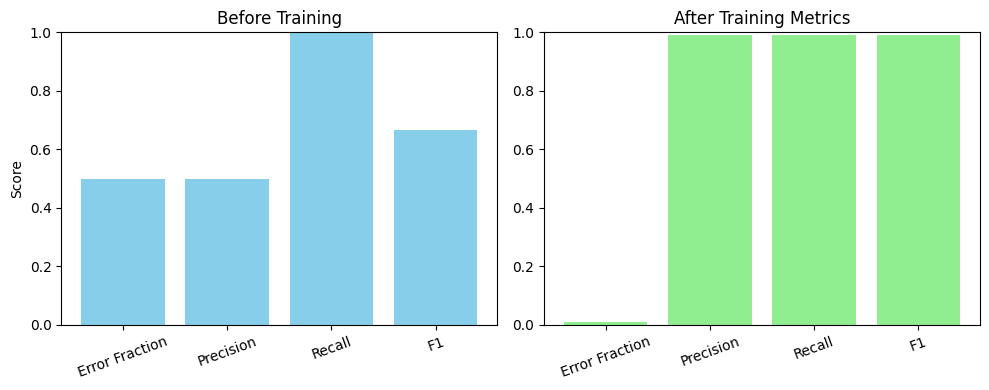

In [36]:
metrics = ['Error Fraction', 'Precision', 'Recall', 'F1']

# Model 1 values
values_1 = [before_error_frac, before_prec_score, before_rec_score, before_f1_score]

# Model 2 values
values_2 = [test_error_frac, test_prec_score, test_rec_score, test_f1_score]

# Create side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar plot for Model 1
axes[0].bar(metrics, values_1, color='skyblue')
axes[0].set_title('Before Training')
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('Score')
axes[0].tick_params(axis='x', rotation=20)

# Bar plot for Model 2
axes[1].bar(metrics, values_2, color='lightgreen')
axes[1].set_title('After Training Metrics')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(os.path.join(os.getcwd(), 'figs/metrics_before_after.png'))
plt.show()

### Inference on The Model!

Perceptron Prediction: 9


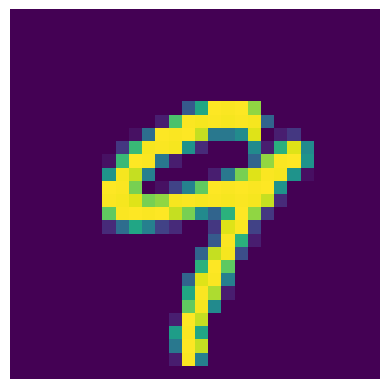

In [20]:
index = random.randint(0, 199)
label, matrix = combined_test_data[index]

perc_output = 9 if perceptron_run(matrix, w) == 1 else 0
print(f"Perceptron Prediction: {perc_output}")
plt.imshow(matrix.reshape(28, 28).T)
plt.axis('off')
plt.show()

### Heatmap

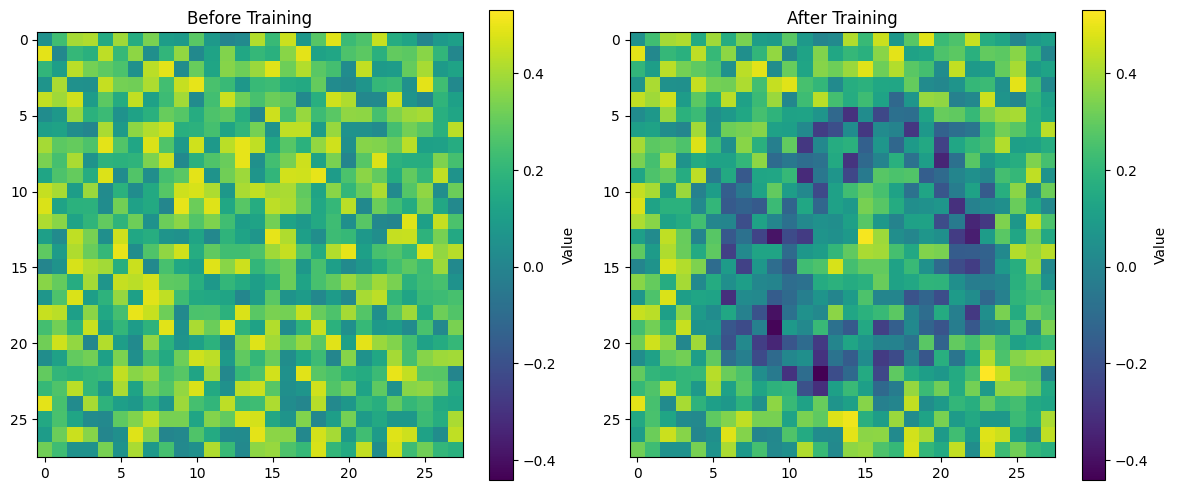

In [37]:
w_initial_matrix = w[1:].reshape(28, 28).T
w_final_matrix = w_trained[1:].reshape(28, 28).T

# Find common color scale
vmin = min(w_initial_matrix.min(), w_final_matrix.min())
vmax = max(w_initial_matrix.max(), w_final_matrix.max())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Before training
im1 = ax1.imshow(w_initial_matrix, cmap='viridis', interpolation='nearest', 
                 vmin=vmin, vmax=vmax)
ax1.set_title('Before Training')
plt.colorbar(im1, ax=ax1, label='Value')

# After training
im2 = ax2.imshow(w_final_matrix, cmap='viridis', interpolation='nearest',
                 vmin=vmin, vmax=vmax)
ax2.set_title('After Training')
plt.colorbar(im2, ax=ax2, label='Value')

plt.tight_layout()
plt.savefig(os.path.join(os.getcwd(), 'figs/heatmap.png'))
plt.show()

### Inference on Challenge Set

Perceptron Prediction: 9 
Actual label: 8


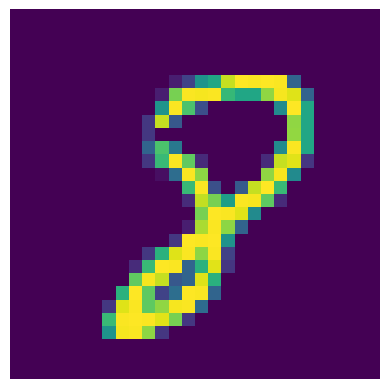

In [25]:
index = random.randint(0, 799)
label, matrix = combined_challenge_data[index]

perc_output = 9 if perceptron_run(matrix, w) == 1 else 0
print(f"Perceptron Prediction: {perc_output} \nActual label: {label}")
plt.imshow(matrix.reshape(28,28).T)
plt.axis('off')
plt.show()

In [39]:
identified_as_zero = {
    1: 0,
    2: 0,
    3: 0,
    4: 0,
    5: 0,
    6: 0,
    7: 0,
    8: 0,
}

identified_as_nine = {
    1: 0,
    2: 0,
    3: 0,
    4: 0,
    5: 0,
    6: 0,
    7: 0,
    8: 0,
}

for label, matrix in combined_challenge_data:
    perc_output = 9 if perceptron_run(matrix, w_trained) == 1 else 0

    if perc_output == 9:
        identified_as_nine[label] += 1
    
    if perc_output == 0:
        identified_as_zero[label] += 1

print(f"identified_as_nine: {identified_as_nine}, identified_as_zero: {identified_as_zero}")

identified_as_nine: {1: 100, 2: 94, 3: 94, 4: 97, 5: 86, 6: 67, 7: 100, 8: 90}, identified_as_zero: {1: 0, 2: 6, 3: 6, 4: 3, 5: 14, 6: 33, 7: 0, 8: 10}


In [40]:
print(f"{'Index':<6}{'Identified as Nine':>20}{'Identified as Zero':>20}")
print("-" * 46)

for k in sorted(identified_as_nine.keys()):
    nine_val = identified_as_nine[k]
    zero_val = identified_as_zero.get(k, '')
    print(f"{k:<6}{nine_val:>20}{zero_val:>20}")

Index   Identified as Nine  Identified as Zero
----------------------------------------------
1                      100                   0
2                       94                   6
3                       94                   6
4                       97                   3
5                       86                  14
6                       67                  33
7                      100                   0
8                       90                  10
